<a href="https://colab.research.google.com/github/zize-a11y/-Computer-Vision-Dasar-Python-Bagian1/blob/main/Pertemuan%204/4.2%20train-yolov8-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Train Yolo V8 using Pytorch & Ultralytics Framework
- Setting GPU Environment
- Installing Ultralytics YOLOv8 on Colab
- Download Dataset from Roboflow (previous notebook)
- Train Custom YOLOv8 Detector
- Infer Custom Objects with Saved YOLOv8 (`.pt`)

⚠️⚠️⚠️ *Please open this notebook in Google Colab* by click below link ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%205/5.1 train-yolov8-object-detection-on-custom-dataset.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1.1 Connect GPU Environment

- Click `Connect` button in top right Google Colab notebook,<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/cl-connect-gpu.png?raw=1" width="250px">
- If connecting process completed, it will turn to something look like this<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Check GPU connected into Colab environment is active

In [19]:
!ls /content/runs/detect/

train  train-2	train2	train-3  train3  train4  train5  train6  val


In [21]:
!ls /content/runs/detect/train6/

args.yaml  weights


In [22]:
!ls /content/runs/detect/train6/weights/

In [9]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.3.1+cu121
Uninstalling torch-2.3.1+cu121:
  Successfully uninstalled torch-2.3.1+cu121
Found existing installation: torchvision 0.18.1+cu121
Uninstalling torchvision-0.18.1+cu121:
  Successfully uninstalled torchvision-0.18.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.3.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.9 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.18.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)


In [10]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.3.1+cu121
Uninstalling torch-2.3.1+cu121:
  Successfully uninstalled torch-2.3.1+cu121
Found existing installation: torchvision 0.18.1+cu121
Uninstalling torchvision-0.18.1+cu121:
  Successfully uninstalled torchvision-0.18.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.3.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.9 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.18.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.0 MB)


In [1]:
!nvidia-smi

Tue Apr 21 14:59:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## 1.2 Installing Ultralytics YOLOv8 on Colab
- `Ultralytics YOLO` is python library that help simplify YOLO training model in `Pytorch`
- It's wrap `Pytorch` functionality as simple CLI command like we use `Darknet` framework
- More about `Ultralytics YOLO` (https://docs.ultralytics.com/)  

In [3]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.12.13 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 56.0/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

### 1.2.1 Ultralytics CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

## 1.3 Download Dataset from Roboflow (previous notebook)

- Back to `Roboflow` > `Project` > `Versions` menu
- Then click `Download Dataset`<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-download-dataset.png?raw=1" width="850px">
- Choose `YOLO Darknet` format and select `Show download code` then click `Continue` <br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-download-format.png?raw=1" width="350px">
- click `Copy` icon to copy roboflow download code<br>
<img src="https://github.com/Muhammad-Yunus/Object-Detection-Yolo-OpenCV-Learn/blob/main/Pertemuan%204/resource/rb-copy-download-code.png?raw=1" width="350px">
- Then replace below code using the copied roboflow download code above,


In [5]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="kWrsbn8TTcIC5WZPEARe")
project = rf.workspace("aurell-s-workspace").project("scissors-auto-annotate-1-uumbr")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


## Custom Training
- Don't forget to change `imgsz=` to image size uploaded in Roboflow
- Default `imgsz=320`

In [6]:
!ls /content

runs  scissors-auto-annotate-1-1  yolo26n.pt  yolov8s.pt


In [7]:
!ls /content/scissors-auto-annotate-1-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [1]:
!yolo task=detect mode=train \
model=yolov8s.pt \
data=/content/scissors-auto-annotate-1-1/data.yaml \
epochs=25 imgsz=320

New https://pypi.org/project/ultralytics/8.4.41 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.12.13 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/scissors-auto-annotate-1-1/data.yaml, epochs=25, patience=50, batch=16, imgsz=320, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_stride=1, stream_buffer=False, line_width=None, visualize=False,

hasil traning

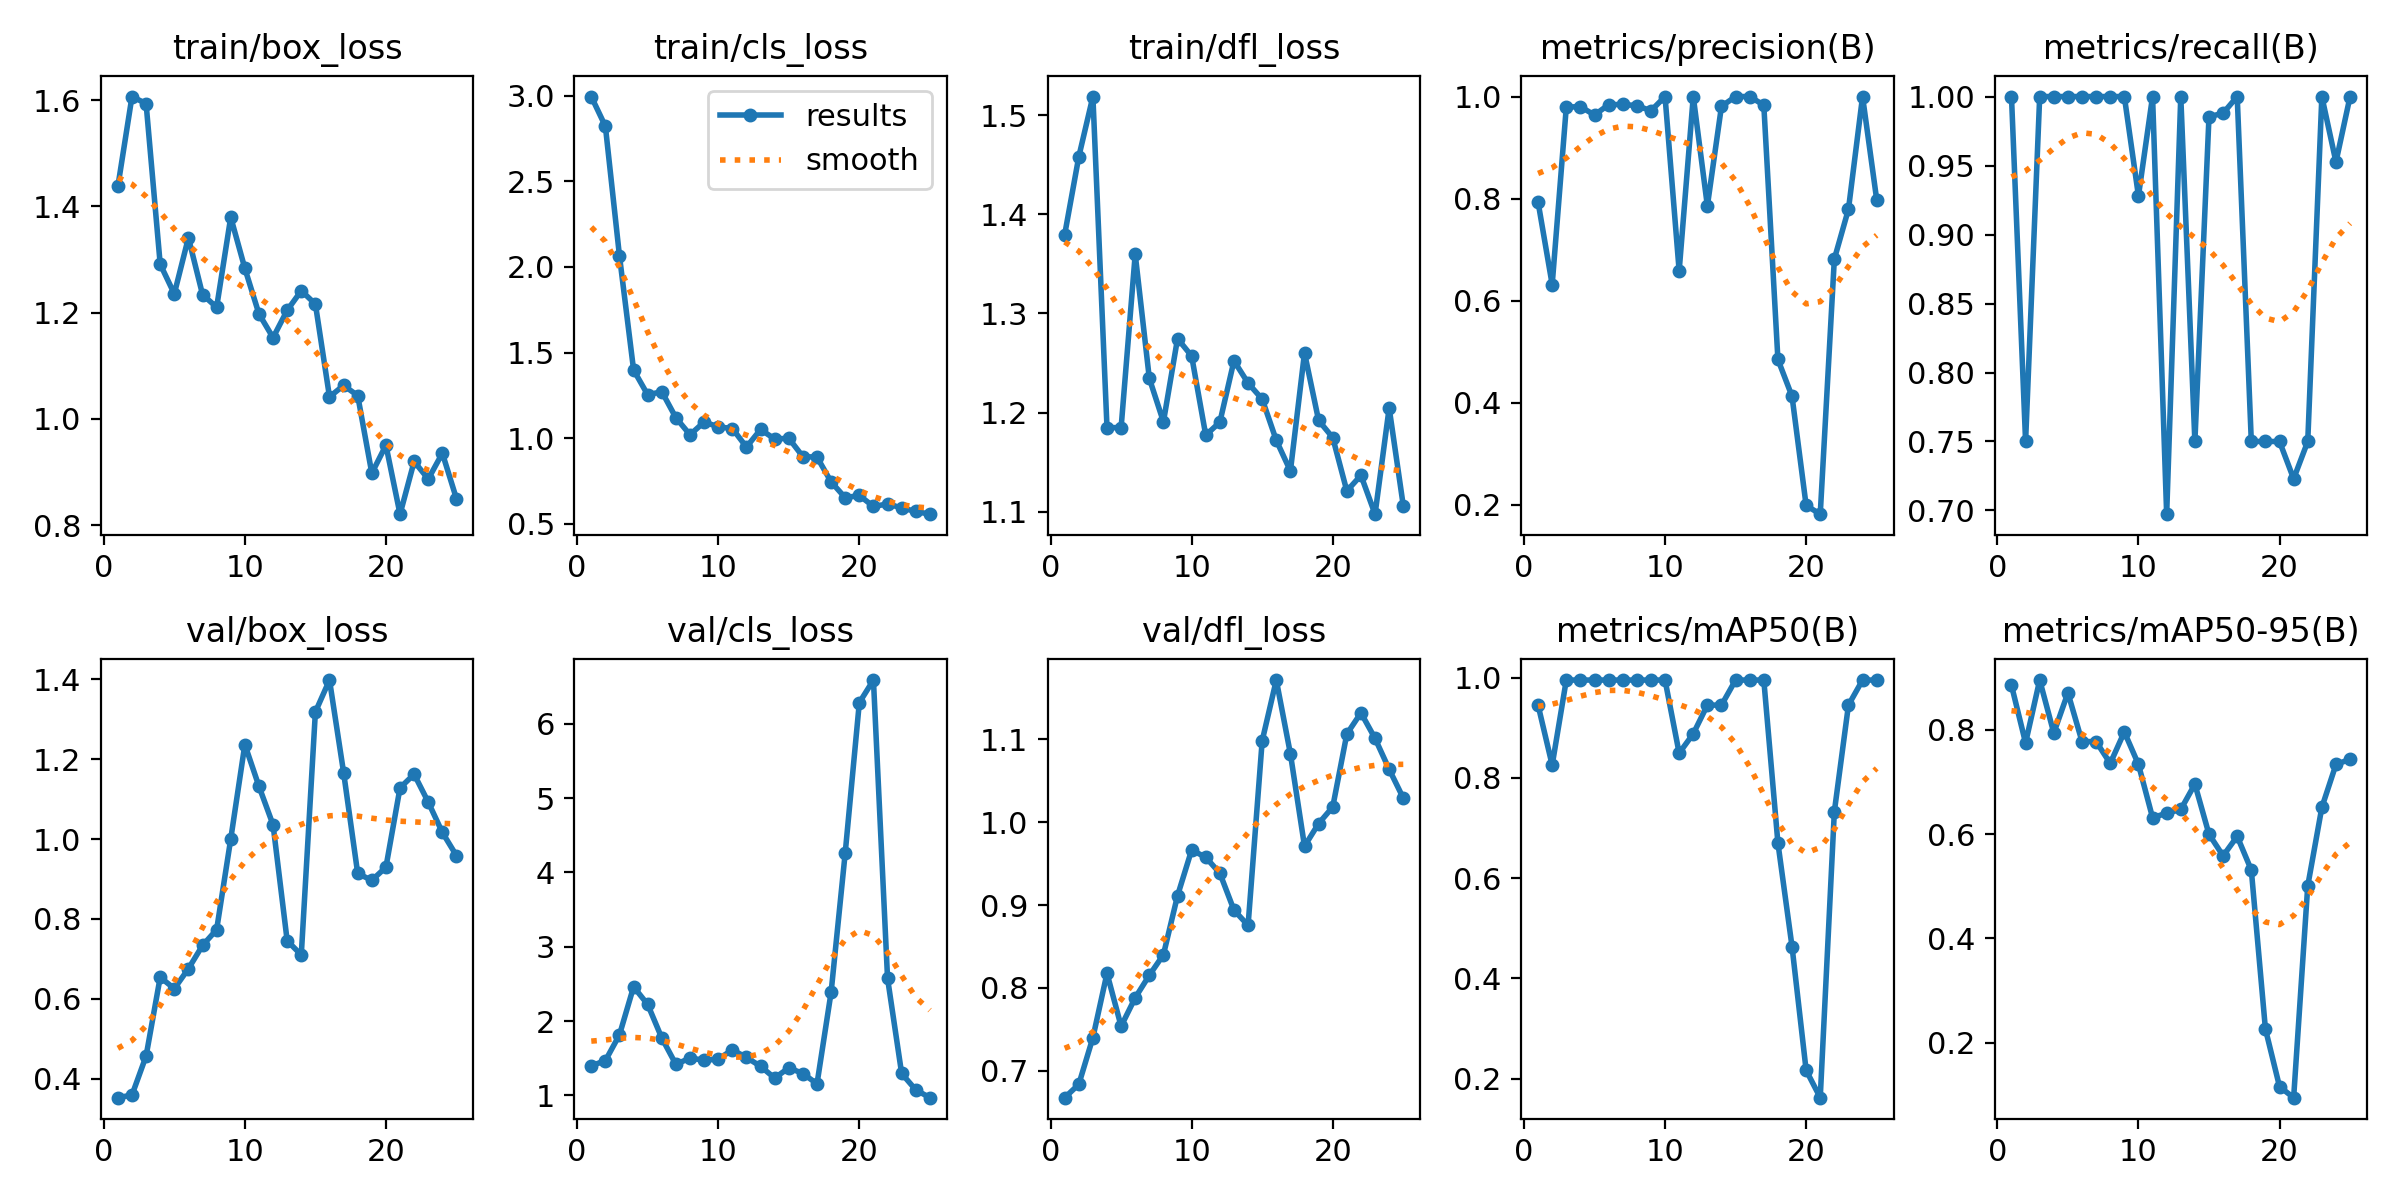

In [11]:
from IPython.display import Image

Image(filename='/content/runs/detect/train3/results.png', width=600)

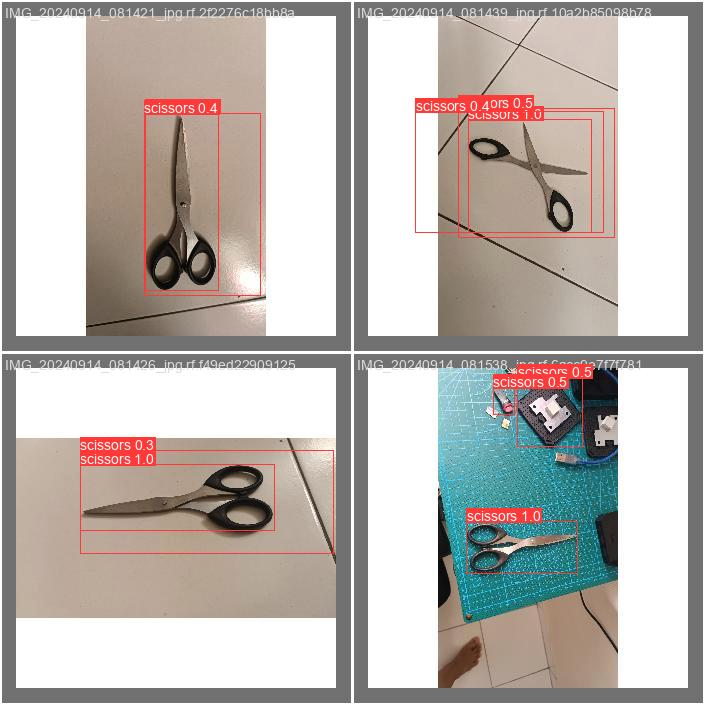

In [12]:
Image(filename='/content/runs/detect/train3/val_batch0_pred.jpg', width=600)

## Export to ONNX
- To use Pytorch (`.pt`) model generated by Utralytic in OpenCV DNN, we will need to convert that into `ONNX` format

In [14]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train3/weights/best.pt")
model.export(format="onnx", opset=12, imgsz=[320, 320])

Ultralytics YOLOv8.0.196 🚀 Python-3.12.13 torch-2.3.1+cu121 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 11125971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/train3/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 5, 2100) (21.4 MB)
requirements: Ultralytics requirement ['onnx>=1.12.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 309.3 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 5.7s, installed 1 package: ['onnx>=1.12.0']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: export success ✅ 6.8s, saved as '/content/runs/detect/train3/weights/best.onnx' (42.5 MB)

Export complete (8.8s)
Results saved to /content/runs/detect/train3/weights
Predict:         yolo predict task=detect model=/content/runs/detect/train3/weights/best.onnx imgsz=320  
Validate:        yolo 

'/content/runs/detect/train3/weights/best.onnx'

In [16]:
from google.colab import files
import shutil

shutil.copy('/content/runs/detect/train3/weights/best.onnx', '/content/yolov8.onnx')
files.download('/content/yolov8.onnx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

________________________________________________________________________

# Source
- https://github.com/roboflow/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb